                    BlockId  E1  E2   E3  E4  E5  E6  E7  E8  E9  ...  E21  \
0  blk_-1608999687919862906   0   0  203   0  10   7   0   0   3  ...   10   
1   blk_7503483334202473044   0   2    1   0   3   0   0   0   3  ...    3   
2  blk_-3544583377289625738   0   0  203   0   3   0   0   0   3  ...    3   
3  blk_-9073992586687739851   0   3    0   0   3   0   0   0   3  ...    3   
4   blk_7854771516489510256   0   3    1  15   3   0   0   0   3  ...    3   

   E22  E23  E24  E25  E26  E27  E28  E29  Label  
0    1   10    0    4   10    0    0    0      0  
1    1    3    0    0    3    0    0    0      0  
2    1    3    0    0    3    0    0    0      1  
3    1    3    0    0    3    0    0    0      0  
4    1    3    0    0    3    0    0    0      0  

[5 rows x 31 columns]
Shape: (575061, 31)
Train shape :  (460048, 29)
Test shape:  (115013, 29)
[[110429   1216]
 [  1316   2052]]
              precision    recall  f1-score   support

           0       0.99      0.99     

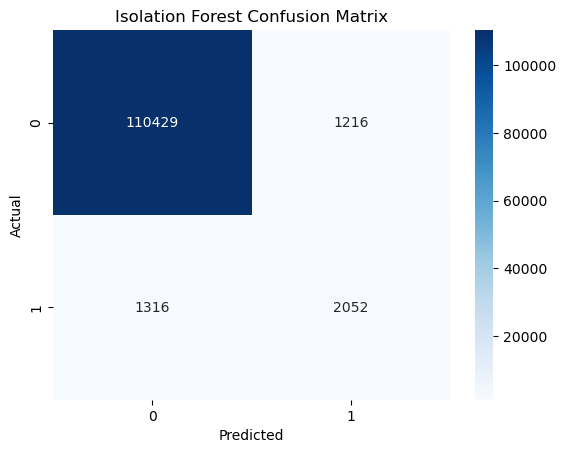

In [1]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import IsolationForest
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

#Loading preprocessed data
df = pd.read_csv("../../Processed_data/processed_hdfs.csv")
print(df.head())
print("Shape:", df.shape)

#Training-Testing spliting
x= df.drop(["BlockId","Label"],axis=1)
y=df["Label"]

x_train , x_test, y_train , y_test = train_test_split(
    x, y, test_size=0.2,
    stratify=y,
    random_state =42
)
print("Train shape : ", x_train.shape)
print("Test shape: ",x_test.shape)

#Isolation Forest
iso=IsolationForest(
    contamination = 0.03, #expected anomaly ratio is nearly 3%
    
    random_state=42
)
iso.fit(x_train)

#predict anomalies
y_pred = iso.predict(x_test)

#convert predictions
y_pred = [1 if x==-1 else 0 for x in y_pred]

#evaluation model
print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test,y_pred))

#Confusion matrix plot
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt ="d",cmap="Blues")

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Isolation Forest Confusion Matrix")

plt.show()




                    BlockId  E1  E2   E3  E4  E5  E6  E7  E8  E9  ...  E21  \
0  blk_-1608999687919862906   0   0  203   0  10   7   0   0   3  ...   10   
1   blk_7503483334202473044   0   2    1   0   3   0   0   0   3  ...    3   
2  blk_-3544583377289625738   0   0  203   0   3   0   0   0   3  ...    3   
3  blk_-9073992586687739851   0   3    0   0   3   0   0   0   3  ...    3   
4   blk_7854771516489510256   0   3    1  15   3   0   0   0   3  ...    3   

   E22  E23  E24  E25  E26  E27  E28  E29  Label  
0    1   10    0    4   10    0    0    0      0  
1    1    3    0    0    3    0    0    0      0  
2    1    3    0    0    3    0    0    0      1  
3    1    3    0    0    3    0    0    0      0  
4    1    3    0    0    3    0    0    0      0  

[5 rows x 31 columns]
Shape: (575061, 31)
Train shape :  (460048, 14)
Test shape:  (115013, 14)
[[108796   2849]
 [   547   2821]]
              precision    recall  f1-score   support

           0       0.99      0.97     

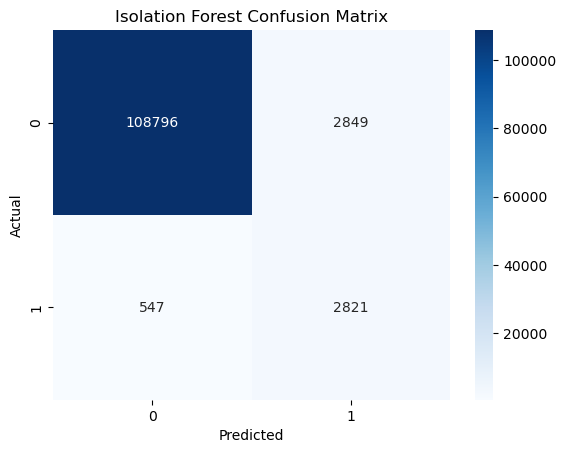

In [3]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import IsolationForest
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import VarianceThreshold
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

#Loading preprocessed data
df = pd.read_csv("../../Processed_data/processed_hdfs.csv")
print(df.head())
print("Shape:", df.shape)

#Training-Testing spliting
x= df.drop(["BlockId","Label"],axis=1)
selector=VarianceThreshold(threshold=0.01)
x=selector.fit_transform(x)
x=np.log1p(x)
y=df["Label"]
scaler=StandardScaler()

x_train , x_test, y_train , y_test = train_test_split(
    x, y, test_size=0.2,
    stratify=y,
    random_state =42
)
#scaling
x_train = scaler.fit_transform(x_train)
x_test = scaler.transform(x_test)
print("Train shape : ", x_train.shape)
print("Test shape: ",x_test.shape)

#Isolation Forest
iso=IsolationForest(
    contamination = 0.05, #expected anomaly ratio is nearly 3%
    n_estimators=300,
    random_state=42
)
iso.fit(x_train)

#predict anomalies
y_pred = iso.predict(x_test)

#convert predictions
y_pred = [1 if x==-1 else 0 for x in y_pred]

#evaluation model
print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test,y_pred))

#Confusion matrix plot
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt ="d",cmap="Blues")

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Isolation Forest Confusion Matrix")

plt.show()




                    BlockId  E1  E2   E3  E4  E5  E6  E7  E8  E9  ...  E21  \
0  blk_-1608999687919862906   0   0  203   0  10   7   0   0   3  ...   10   
1   blk_7503483334202473044   0   2    1   0   3   0   0   0   3  ...    3   
2  blk_-3544583377289625738   0   0  203   0   3   0   0   0   3  ...    3   
3  blk_-9073992586687739851   0   3    0   0   3   0   0   0   3  ...    3   
4   blk_7854771516489510256   0   3    1  15   3   0   0   0   3  ...    3   

   E22  E23  E24  E25  E26  E27  E28  E29  Label  
0    1   10    0    4   10    0    0    0      0  
1    1    3    0    0    3    0    0    0      0  
2    1    3    0    0    3    0    0    0      1  
3    1    3    0    0    3    0    0    0      0  
4    1    3    0    0    3    0    0    0      0  

[5 rows x 31 columns]
Shape: (575061, 31)
Train shape :  (460048, 14)
Test shape:  (115013, 14)
[[108796   2849]
 [   547   2821]]
              precision    recall  f1-score   support

           0       0.99      0.97     

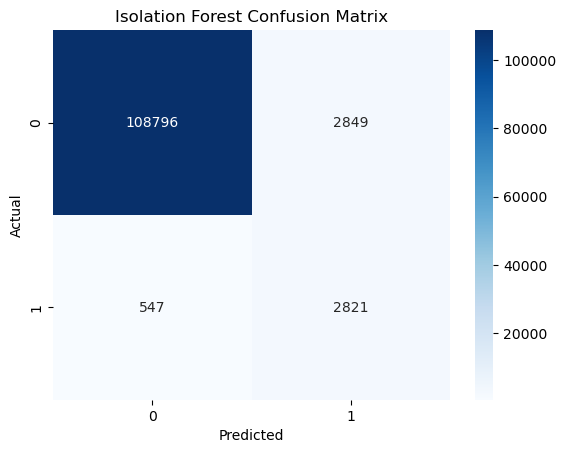

ROC-Auc 0.9376670813782529


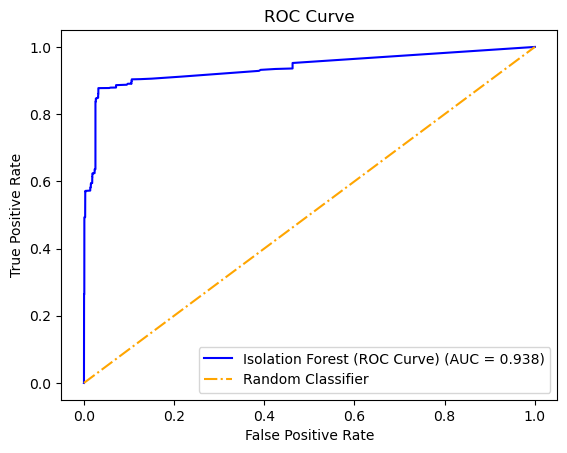

In [4]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import IsolationForest
from sklearn.metrics import classification_report, confusion_matrix, roc_curve
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import VarianceThreshold
from sklearn.metrics import roc_auc_score
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

#Loading preprocessed data
df = pd.read_csv("../../Processed_data/processed_hdfs.csv")
print(df.head())
print("Shape:", df.shape)

#Training-Testing spliting
x= df.drop(["BlockId","Label"],axis=1)
'''Remove Weak Features
Some event columns might be useless.'''
selector=VarianceThreshold(threshold=0.01)
'''Isolation Forest works better when features are scaled.'''
x=selector.fit_transform(x)
'''Instead of raw event counts:
E1 E2 E3 ...
use log-transformed features:'''
x=np.log1p(x)
y=df["Label"]
scaler=StandardScaler()

x_train , x_test, y_train , y_test = train_test_split(
    x, y, test_size=0.2,
    stratify=y,
    random_state =42
)
# feature scaling
x_train = scaler.fit_transform(x_train)
x_test = scaler.transform(x_test)
print("Train shape : ", x_train.shape)
print("Test shape: ",x_test.shape)

#Isolation Forest
iso=IsolationForest(
    contamination = 0.05, #expected anomaly ratio is nearly 3%
    n_estimators=300, #increasing number of trees (default = 100) More trees → better anomaly detection.
    random_state=42
)
iso.fit(x_train)

#predict anomalies
y_pred = iso.predict(x_test)

#convert predictions
y_pred = [1 if x==-1 else 0 for x in y_pred]

#evaluation model
print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test,y_pred))

#Confusion matrix plot
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt ="d",cmap="Blues")

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Isolation Forest Confusion Matrix")

plt.show()

scores = iso.decision_function(x_test)
auc=roc_auc_score(y_test,-scores)
print("ROC-Auc",auc)

fpr, tpr, _ = roc_curve(y_test, -scores)
plt.plot(fpr, tpr, color='blue', label=f'Isolation Forest (ROC Curve) (AUC = {auc:.3f})')
plt.plot([0,1],[0,1],linestyle='dashdot', color='orange', label='Random Classifier')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend(loc="lower right")
plt.show()




                    BlockId  E1  E2   E3  E4  E5  E6  E7  E8  E9  ...  E21  \
0  blk_-1608999687919862906   0   0  203   0  10   7   0   0   3  ...   10   
1   blk_7503483334202473044   0   2    1   0   3   0   0   0   3  ...    3   
2  blk_-3544583377289625738   0   0  203   0   3   0   0   0   3  ...    3   
3  blk_-9073992586687739851   0   3    0   0   3   0   0   0   3  ...    3   
4   blk_7854771516489510256   0   3    1  15   3   0   0   0   3  ...    3   

   E22  E23  E24  E25  E26  E27  E28  E29  Label  
0    1   10    0    4   10    0    0    0      0  
1    1    3    0    0    3    0    0    0      0  
2    1    3    0    0    3    0    0    0      1  
3    1    3    0    0    3    0    0    0      0  
4    1    3    0    0    3    0    0    0      0  

[5 rows x 31 columns]
Shape: (575061, 31)
Train shape :  (460048, 14)
Test shape:  (115013, 14)
[[108796   2849]
 [   547   2821]]
              precision    recall  f1-score   support

           0       0.99      0.97     

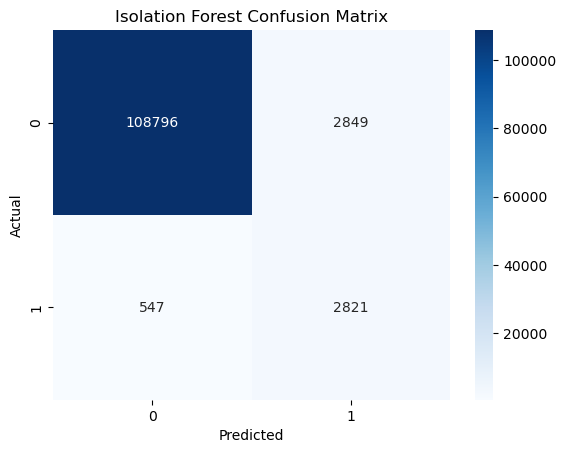

ROC-Auc 0.9376670813782529


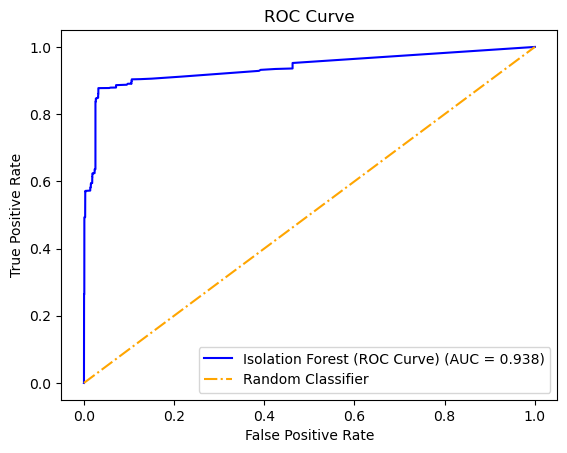

In [5]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import IsolationForest
from sklearn.metrics import classification_report, confusion_matrix, roc_curve
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import VarianceThreshold
from sklearn.metrics import roc_auc_score
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

#Loading preprocessed data
df = pd.read_csv("../../Processed_data/processed_hdfs.csv")
print(df.head())
print("Shape:", df.shape)

#Training-Testing spliting
x= df.drop(["BlockId","Label"],axis=1)
'''Remove Weak Features
Some event columns might be useless.'''
selector=VarianceThreshold(threshold=0.01)
'''Isolation Forest works better when features are scaled.'''
x=selector.fit_transform(x)
'''Instead of raw event counts:
E1 E2 E3 ...
use log-transformed features:'''
x=np.log1p(x)
y=df["Label"]
scaler=StandardScaler()

x_train , x_test, y_train , y_test = train_test_split(
    x, y, test_size=0.2,
    stratify=y,
    random_state =42
)
# feature scaling
x_train = scaler.fit_transform(x_train)
x_test = scaler.transform(x_test)
print("Train shape : ", x_train.shape)
print("Test shape: ",x_test.shape)

#Isolation Forest
iso=IsolationForest(
    contamination = 0.05, #expected anomaly ratio is nearly 3%
    n_estimators=300, #increasing number of trees (default = 100) More trees → better anomaly detection.
    max_samples='auto',
    max_features=1.0,
    bootstrap=False,
    random_state=42
)
iso.fit(x_train)

#predict anomalies
y_pred = iso.predict(x_test)

#convert predictions
y_pred = [1 if x==-1 else 0 for x in y_pred]

#evaluation model
print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test,y_pred))

#Confusion matrix plot
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt ="d",cmap="Blues")

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Isolation Forest Confusion Matrix")

plt.show()
#Isolation Forest gives anomaly scores, which are perfect for AUC.
scores = iso.decision_function(x_test)
auc=roc_auc_score(y_test,-scores)
print("ROC-Auc",auc)

fpr, tpr, _ = roc_curve(y_test, -scores)
plt.plot(fpr, tpr, color='blue', label=f'Isolation Forest (ROC Curve) (AUC = {auc:.3f})')
plt.plot([0,1],[0,1],linestyle='dashdot', color='orange', label='Random Classifier')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend(loc="lower right")
plt.show()


